
# LangGraph Reflection 机制开发指南

本指南详细介绍了如何在 **LangGraph** 中构建基于大语言模型（LLM）的 **Reflection（反思）** 机制。

Reflection 是一种重要的模型能力，通过让模型观察其过去的步骤和外部环境反馈，评估自身行为的质量，并不断改进输出。在生成与反思的循环中，模型可以逐步优化内容，从而提升生成质量和用户满意度。

Reflection 机制被广泛应用于生成任务中，例如文章写作、内容修改与反馈、以及智能助理等场景。通过引导 LLM 进行自我反思和用户反馈处理，开发者可以让模型在多轮交互中自动调整其生成的内容，达到高效、精准、结构完善的输出。



在本指南中，我们会逐步演示如何搭建这一机制，包括从基础的环境配置到生成器和反思器的构建，再到如何使用 LangGraph 状态图实现生成-反思循环的完整流程。无论您是为文章生成、内容评估，还是其他复杂任务设计 LLM 代理，本指南都将为您提供详细的开发思路和实用的代码示例。

![reflection](./images/reflection.png)

通过本指南，您将学习如何：
1. 设置开发环境并安装所需包；
2. 定义和生成灵活结构的文章，不局限于传统的五段式；
3. 通过反思机制批改生成内容，并提供详细反馈；
4. 构建反思与生成的状态循环，使模型持续改进生成内容。

本开发指南适合任何希望构建复杂 LLM 任务的开发者，特别是需要实现生成-反思流程、文章批改反馈、或其他高级交互任务的场景。


## 1. 环境设置
首先，安装所需的包并设置API密钥：

In [5]:
%%capture --no-stderr
%pip install langchain langgraph langchain-ollama tavily-python langchain_openai

In [11]:
import getpass
import os

# 定义一个帮助函数来检查环境变量，如果不存在则提示用户输入
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"请输入您的 {var}")

# 设置 OpenAI 和 Langchain API 密钥
_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("LANGCHAIN_API_KEY")
_set_if_undefined("TAVILY_API_KEY")


## 2. LangSmith开发配置
LangSmith能够帮助您快速发现问题并提高LangGraph项目的性能。通过LangSmith，您可以使用跟踪数据来调试、测试和监控基于LangGraph构建的LLM应用程序。

In [12]:
# 在 LangSmith 中添加追踪功能
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Reflection"

## 3. 定义写作助手智能体

我们定义的这个助手是一个写作助手，旨在为用户生成高质量、结构清晰且引人入胜的文章。它的任务是根据用户的请求撰写内容，无论是短文、长篇、议论文还是其他类型的文章，都能够灵活应对。助手会专注于文章的清晰度、结构和质量，确保输出的内容是精心打磨过的。如果用户对生成的内容有反馈或建议，助手还能够根据这些反馈改进和优化文章，使其更符合用户的期望。这种互动机制保证了写作过程的灵活性和个性化，从而让用户获得更符合需求的成品。


### System Prompt 详细解释：
1. **"You are a writing assistant"**：写作助手的角色设定，让模型明确其任务是帮助用户进行写作。
   
2. **"well-crafted, coherent, and engaging articles"**：描述了文章应该具备的特性，包括“精心撰写的、连贯的和吸引人的”，但没有限制文章的具体结构，可以是不同类型的文章（如叙述文、议论文等）。

3. **"Focus on clarity, structure, and quality"**：明确了撰写时需要关注的核心要素：清晰度、结构性和质量，确保输出内容优秀。

4. **"revise and improve the writing"**：模型可以根据用户的反馈进行修改和优化，保持互动的灵活性。


In [31]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from langchain_ollama.chat_models import ChatOllama

writer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a versatile assistant tasked with generating high-quality content across various domains, including code, reports, articles, and more."
            " Focus on clarity, structure, and relevance to ensure the produced content meets the user's requirements."
            " If the user provides feedback or suggestions, revise and enhance the output to better align with their expectations.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

llm = ChatOpenAI(model="gpt-4o-mini")

In [23]:
# writer = writer_prompt | ChatOllama(
#     model="llama3.1:8b-instruct-q8_0",
#     max_tokens=8192,
#     temperature=1.2,
# )

In [32]:
writer = writer_prompt | llm

In [33]:
article = ""

topic = HumanMessage(
    content="把西游记中三打白骨精的情节用python代码讲解一下"
)

for chunk in writer.stream({"messages": [topic]}):
    print(chunk.content, end="")
    article += chunk.content

好的，下面我将用 Python 代码模拟《西游记》中“三打白骨精”的情节。这个过程将通过定义几个类和方法来表示角色和他们的行为。

### 角色定义
我们定义三个主要角色：唐僧、孙悟空和白骨精。我们将使用类来表示这些角色，并添加他们的行为。

### Python代码示例

```python
class Character:
    def __init__(self, name):
        self.name = name
        self.is_alive = True

    def speak(self, message):
        print(f"{self.name}: {message}")

class TangSeng(Character):
    def __init__(self):
        super().__init__("唐僧")

class SunWukong(Character):
    def __init__(self):
        super().__init__("孙悟空")

    def attack(self, target):
        if target.is_alive:
            target.is_alive = False
            print(f"{self.name} uses the golden staff to attack {target.name}!")
            print(f"{target.name} is defeated!")
        else:
            print(f"{target.name} is already defeated.")

class BaiGuJing(Character):
    def __init__(self):
        super().__init__("白骨精")

    def disguise(self):
        self.is_alive = True
        print(f"{self.name} disguises as a beautiful woman to trick 唐僧.")

#

In [34]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(article))

好的，下面我将用 Python 代码模拟《西游记》中“三打白骨精”的情节。这个过程将通过定义几个类和方法来表示角色和他们的行为。

### 角色定义
我们定义三个主要角色：唐僧、孙悟空和白骨精。我们将使用类来表示这些角色，并添加他们的行为。

### Python代码示例

```python
class Character:
    def __init__(self, name):
        self.name = name
        self.is_alive = True

    def speak(self, message):
        print(f"{self.name}: {message}")

class TangSeng(Character):
    def __init__(self):
        super().__init__("唐僧")

class SunWukong(Character):
    def __init__(self):
        super().__init__("孙悟空")

    def attack(self, target):
        if target.is_alive:
            target.is_alive = False
            print(f"{self.name} uses the golden staff to attack {target.name}!")
            print(f"{target.name} is defeated!")
        else:
            print(f"{target.name} is already defeated.")

class BaiGuJing(Character):
    def __init__(self):
        super().__init__("白骨精")

    def disguise(self):
        self.is_alive = True
        print(f"{self.name} disguises as a beautiful woman to trick 唐僧.")

# 实例化角色
tang_seng = TangSeng()
sun_wukong = SunWukong()
bai_gu_jing = BaiGuJing()

# 情节开始
print("白骨精开始用美丽的外表来诱惑唐僧...")
bai_gu_jing.disguise()

# 第一幕：第一次攻击
print("\n第一次攻击:")
sun_wukong.attack(bai_gu_jing)

# 白骨精复活并再次伪装
bai_gu_jing = BaiGuJing()  # 复活白骨精
print("\n白骨精再次伪装...")
bai_gu_jing.disguise()

# 第二幕：第二次攻击
print("\n第二次攻击:")
sun_wukong.attack(bai_gu_jing)

# 白骨精复活并再次伪装
bai_gu_jing = BaiGuJing()  # 复活白骨精
print("\n白骨精再次伪装...")
bai_gu_jing.disguise()

# 第三幕：第三次攻击
print("\n第三次攻击:")
sun_wukong.attack(bai_gu_jing)

# 结果
if not bai_gu_jing.is_alive:
    print("\n白骨精被打败，唐僧安全了！")
else:
    print("\n白骨精依然活着，唐僧仍需小心。")
```

### 代码解释
1. **角色类**：我们定义了一个基类 `Character`，并从中派生出 `TangSeng`、`SunWukong` 和 `BaiGuJing` 类。
2. **攻击和伪装**：`SunWukong` 类中有一个 `attack` 方法，用于攻击目标，而 `BaiGuJing` 类有一个 `disguise` 方法，用于伪装。
3. **情节模拟**：通过调用方法，模拟了白骨精的伪装和孙悟空的三次攻击。

这个代码示例展示了《西游记》中三打白骨精的基本情节，通过程序化的方式来表达故事的进展和角色之间的互动。你可以运行这段代码，观察情节的推进。

----------
## 4. 定义审阅老师智能体

下面我们使用反思机制批改生成的作文，生成一篇作文的反馈和建议。

模型扮演“老师”角色，针对用户提交的作文进行打分、批改和提供改进建议。

### System Prompt 详细解释：

- **"You are a teacher grading an essay submission."**
  - 模型被设定为一个老师角色，专门负责为用户提交的作文进行批改。这一角色定位帮助模型理解其任务是提供具有建设性的反馈和评价。
  
- **"Generate critique and recommendations for the user's submission."**
  - 模型需要生成作文的批评与建议。它不只是评估作文的好坏，还需要指出需要改进的地方，并提出具体的建议。

- **"Provide detailed recommendations, including requests for length, depth, style, etc."**
  - 这一部分进一步明确了反馈的细节，要求模型给出细致的建议。这包括：
    - **Length（长度）**：文章的字数是否合适，是否需要扩展或删减。
    - **Depth（深度）**：是否需要更深入的分析或讨论。
    - **Style（风格）**：文章的写作风格是否合适，是否符合目标读者或主题的需求。
  
这一设定确保了模型不仅给出基本反馈，还可以根据文章的具体问题提出具体的改进意见，帮助用户更好地提升其写作。

In [35]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a reviewer tasked with providing constructive critique and improvement suggestions for the user's submission."
            " Offer detailed feedback, including recommendations on clarity, structure, content depth, and style, as well as areas for improvement.",

        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# reflect = reflection_prompt | ChatOllama(
#     model="llama3.1:8b-instruct-q8_0",
#     max_tokens=8192,
#     temperature=0.2,
# )

reflect = reflection_prompt | llm

In [36]:
reflection = ""

# 将主题（topic）和生成的文章（article）作为输入发送给反思智能体
for chunk in reflect.stream({"messages": [topic, HumanMessage(content=article)]}):
    print(chunk.content, end="")
    reflection += chunk.content

你的代码展示了《西游记》中“三打白骨精”的情节，整体结构和思路都不错。以下是我对你的代码和实现的详细反馈，包括一些改进建议：

### 1. 清晰度与注释
- **建议**：在每个主要部分之前添加注释，以便读者能够更容易理解代码的意图。例如，在角色定义、情节开始、每次攻击之前添加注释。
- **示例**：
  ```python
  # 定义角色类
  ```

### 2. 角色复活逻辑
- **问题**：在每次攻击后，你创建了一个新的 `BaiGuJing` 实例来模拟复活，但这可能会让人误解为白骨精被打败后就会被重新创建。
- **建议**：可以在 `BaiGuJing` 类中添加一个复活方法，这样更加符合逻辑，同时能增强代码的可读性。
  
### 3. 角色状态管理
- **建议**：可以增加角色的状态管理，比如白骨精在被打败后是否需要恢复到初始状态，或者是否有其他的状态（如愤怒、受伤等）。

### 4. 攻击次数记录
- **建议**：可以在 `SunWukong` 类中记录攻击次数，并在攻击时输出当前攻击次数，这样会更好地反映“三打”的情节。
  
### 5. 细节丰富
- **建议**：在角色说话时可以增加更多的台词，例如孙悟空在攻击前后的对话内容，或者唐僧的反应。这样可以增强故事的表现力。
  
### 6. 代码结构
- **建议**：可以考虑将情节模拟的过程抽象成一个方法，例如 `simulate_battles()`，这样可以使代码更加模块化，且易于扩展。

### 7. 示例代码改进

以下是改进后的代码示例：

```python
class Character:
    def __init__(self, name):
        self.name = name
        self.is_alive = True

    def speak(self, message):
        print(f"{self.name}: {message}")

class TangSeng(Character):
    def __init__(self):
        super().__init__("唐僧")

class SunWukong(Character):
    def __init__(self)

In [37]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(reflection))

你的代码展示了《西游记》中“三打白骨精”的情节，整体结构和思路都不错。以下是我对你的代码和实现的详细反馈，包括一些改进建议：

### 1. 清晰度与注释
- **建议**：在每个主要部分之前添加注释，以便读者能够更容易理解代码的意图。例如，在角色定义、情节开始、每次攻击之前添加注释。
- **示例**：
  ```python
  # 定义角色类
  ```

### 2. 角色复活逻辑
- **问题**：在每次攻击后，你创建了一个新的 `BaiGuJing` 实例来模拟复活，但这可能会让人误解为白骨精被打败后就会被重新创建。
- **建议**：可以在 `BaiGuJing` 类中添加一个复活方法，这样更加符合逻辑，同时能增强代码的可读性。
  
### 3. 角色状态管理
- **建议**：可以增加角色的状态管理，比如白骨精在被打败后是否需要恢复到初始状态，或者是否有其他的状态（如愤怒、受伤等）。

### 4. 攻击次数记录
- **建议**：可以在 `SunWukong` 类中记录攻击次数，并在攻击时输出当前攻击次数，这样会更好地反映“三打”的情节。
  
### 5. 细节丰富
- **建议**：在角色说话时可以增加更多的台词，例如孙悟空在攻击前后的对话内容，或者唐僧的反应。这样可以增强故事的表现力。
  
### 6. 代码结构
- **建议**：可以考虑将情节模拟的过程抽象成一个方法，例如 `simulate_battles()`，这样可以使代码更加模块化，且易于扩展。

### 7. 示例代码改进

以下是改进后的代码示例：

```python
class Character:
    def __init__(self, name):
        self.name = name
        self.is_alive = True

    def speak(self, message):
        print(f"{self.name}: {message}")

class TangSeng(Character):
    def __init__(self):
        super().__init__("唐僧")

class SunWukong(Character):
    def __init__(self):
        super().__init__("孙悟空")
        self.attack_count = 0

    def attack(self, target):
        self.attack_count += 1
        if target.is_alive:
            target.is_alive = False
            print(f"{self.name} uses the golden staff to attack {target.name}! (Attack #{self.attack_count})")
            print(f"{target.name} is defeated!")
        else:
            print(f"{target.name} is already defeated.")

class BaiGuJing(Character):
    def __init__(self):
        super().__init__("白骨精")

    def disguise(self):
        self.is_alive = True
        print(f"{self.name} disguises as a beautiful woman to trick 唐僧.")

    def revive(self):
        self.is_alive = True
        print(f"{self.name} has revived!")

# 实例化角色
tang_seng = TangSeng()
sun_wukong = SunWukong()
bai_gu_jing = BaiGuJing()

# 情节开始
print("白骨精开始用美丽的外表来诱惑唐僧...")
bai_gu_jing.disguise()

# 三次攻击
for i in range(3):
    print(f"\n第{i + 1}次攻击:")
    sun_wukong.attack(bai_gu_jing)
    
    if bai_gu_jing.is_alive:
        bai_gu_jing.revive()  # 复活白骨精
        print("\n白骨精再次伪装...")
        bai_gu_jing.disguise()

# 结果
if not bai_gu_jing.is_alive:
    print("\n白骨精被打败，唐僧安全了！")
else:
    print("\n白骨精依然活着，唐僧仍需小心。")
```

### 总结
你的实现已经很好地表现了故事情节，通过以上建议的改进，可以进一步提升代码的可读性和逻辑性。希望这些反馈对你有所帮助！

In [46]:
from typing import Annotated  # 用于类型注解
from langgraph.graph import END, StateGraph, START  # 导入状态图的相关常量和类
from langgraph.graph.message import add_messages  # 用于在状态中处理消息
from langgraph.checkpoint.memory import MemorySaver  # 内存保存机制，用于保存检查点
from typing_extensions import TypedDict  # 用于定义带有键值对的字典类型

# 定义状态类，使用TypedDict以保存消息
class State(TypedDict):
    messages: Annotated[list, add_messages]  # 使用注解确保消息列表使用add_messages方法处理

# 异步生成节点函数：生成内容（如作文）
# 输入状态，输出包含新生成消息的状态
async def generation_node(state: State) -> State:
    # 调用生成器(writer)，并将消息存储到新的状态中返回
    return {"messages": [await writer.ainvoke(state['messages'])]}

# 异步反思节点函数：对生成的内容进行反思和反馈
# 输入状态，输出带有反思反馈的状态
async def reflection_node(state: State) -> State:
    # 创建一个消息类型映射，ai消息映射为HumanMessage，human消息映射为AIMessage
    cls_map = {"ai": HumanMessage, "human": AIMessage}
    
    # 处理消息，保持用户的原始请求（第一个消息），转换其余消息的类型
    translated = [state['messages'][0]] + [
        cls_map[msg.type](content=msg.content) for msg in state['messages'][1:]
    ]
    
    # 调用反思器(reflect)，将转换后的消息传入，获取反思结果
    res = await reflect.ainvoke(translated)
    
    # 返回新的状态，其中包含反思后的消息
    return {"messages": [HumanMessage(content=res.content)]}


In [47]:
MAX_ROUND = 6

# 定义条件函数，决定是否继续反思过程
# 如果消息数量超过6条，则终止流程
def should_continue(state: State):
    if len(state["messages"]) > MAX_ROUND:
        return END  # 达到条件时，流程结束
    return "reflect"  # 否则继续进入反思节点

In [48]:
# 创建状态图，传入初始状态结构
builder = StateGraph(State)

# 在状态图中添加"writer"节点，节点负责生成内容
builder.add_node("writer", generation_node)

# 在状态图中添加"reflect"节点，节点负责生成反思反馈
builder.add_node("reflect", reflection_node)

# 定义起始状态到"writer"节点的边，从起点开始调用生成器
builder.add_edge(START, "writer")


# 在"writer"节点和"reflect"节点之间添加条件边
# 判断是否需要继续反思，或者结束
builder.add_conditional_edges("writer", should_continue)

# 添加从"reflect"节点回到"writer"节点的边，进行反复的生成-反思循环
builder.add_edge("reflect", "writer")

# 创建内存保存机制，允许在流程中保存中间状态和检查点
memory = MemorySaver()

# 编译状态图，使用检查点机制
graph = builder.compile(checkpointer=memory)

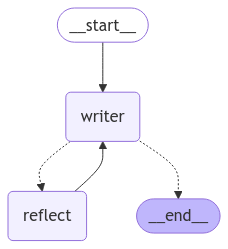

In [49]:
# 可视化图
from IPython.display import Image, display

try:
    display(
        Image(
            graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

In [50]:
from IPython.display import Markdown, display

# 定义装饰器，记录函数调用次数
def track_steps(func):
    step_counter = {'count': 0}  # 用于记录调用次数
    
    def wrapper(event, *args, **kwargs):
        # 增加调用次数
        step_counter['count'] += 1
        # 在函数调用之前打印 step
        display(Markdown(f"## Round {step_counter['count']}"))
        # 调用原始函数
        return func(event, *args, **kwargs)
    
    return wrapper

# 使用装饰器装饰 pretty_print_event_markdown 函数
@track_steps
def pretty_print_event_markdown(event):
    # 如果是生成写作部分
    if 'writer' in event:
        generate_md = "#### 写作生成:\n"
        for message in event['writer']['messages']:
            generate_md += f"- {message.content}\n"
        display(Markdown(generate_md))
    
    # 如果是反思评论部分
    if 'reflect' in event:
        reflect_md = "#### 评论反思:\n"
        for message in event['reflect']['messages']:
            reflect_md += f"- {message.content}\n"
        display(Markdown(reflect_md))

In [51]:
inputs = {
    "messages": [
        HumanMessage(content="让孙悟空教猪八戒学python，采用剧本方式表述，学个简单的排序算法题")
    ],
}

config = {"configurable": {"thread_id": "1"}}

async for event in graph.astream(inputs, config):
    pretty_print_event_markdown(event)


## Round 1

#### 写作生成:
- 标题：孙悟空教猪八戒学Python

场景：花果山的一个阳光明媚的下午，孙悟空和猪八戒坐在一块大石头上，阳光透过树叶洒在他们身上。猪八戒正在为排序问题烦恼。

---

**角色：**

- 孙悟空（悟空）
- 猪八戒（八戒）

---

**[场景一：石头上]**

**八戒**：悟空，我听说Python可以用来编程，可是我对排序算法一窍不通，能不能教教我？

**悟空**：没问题，八戒！排序算法就像把一堆乱七八糟的东西整理成一个整齐的队伍。我们今天就一起学一个简单的排序算法——冒泡排序。

**八戒**：冒泡排序？这听起来像是我吃的泡饭！

---

**[场景二：悟空拿出纸和笔]**

**悟空**：首先，想象一下你有一列数字，比如说：[5, 3, 8, 4, 2]。我们的目标就是把它们从小到大排序。

**八戒**：好，我们开始吧！

**悟空**：冒泡排序的基本思想是：从头到尾比较相邻的两个元素，如果前面的元素比后面的元素大，就交换它们的位置。这样，最大的元素就会“冒泡”到最后。

---

**[场景三：示范排序过程]**

**悟空**：看，我来给你演示一下。

1. **初始列表**：[5, 3, 8, 4, 2]
2. **第一轮比较**：
   - 比较5和3，5 > 3，交换 → [3, 5, 8, 4, 2]
   - 比较5和8，5 < 8，不交换 → [3, 5, 8, 4, 2]
   - 比较8和4，8 > 4，交换 → [3, 5, 4, 8, 2]
   - 比较8和2，8 > 2，交换 → [3, 5, 4, 2, 8]

3. **第二轮比较**：
   - 比较3和5，3 < 5，不交换 → [3, 5, 4, 2, 8]
   - 比较5和4，5 > 4，交换 → [3, 4, 5, 2, 8]
   - 比较5和2，5 > 2，交换 → [3, 4, 2, 5, 8]
   - 比较5和8，5 < 8，不交换 → [3, 4, 2, 5, 8]

4. **第三轮比较**：
   - 比较3和4，3 < 4，不交换 → [3, 4, 2, 5, 8]
   - 比较4和2，4 > 2，交换 → [3, 2, 4, 5, 8]
   - 比较4和5，4 < 5，不交换 → [3, 2, 4, 5, 8]
   - 比较5和8，5 < 8，不交换 → [3, 2, 4, 5, 8]

5. **最后一轮，直到没有交换为止**。

**八戒**：明白了，所以我们不断比较、交换，直到所有数字都排好顺序。

---

**[场景四：总结]**

**悟空**：对了，八戒！现在你能用Python写出这个冒泡排序的代码吗？

**八戒**：我试试！

```python
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

# 测试
numbers = [5, 3, 8, 4, 2]
sorted_numbers = bubble_sort(numbers)
print("排序后的列表:", sorted_numbers)
```

**悟空**：太棒了，八戒！你学会了！现在你可以把任何一堆数字都排好顺序了！

**八戒**：谢谢悟空！我觉得编程真有趣，等会儿我去试试别的算法！

---

**[场景结束]**

（阳光继续洒在花果山上，悟空和八戒开心地讨论着更多的编程知识。）

---

**剧本完**


## Round 2

#### 评论反思:
- 标题：孙悟空教猪八戒学Python

场景：花果山的一个阳光明媚的下午，孙悟空和猪八戒坐在一块大石头上，阳光透过树叶洒在他们身上。猪八戒正在为排序问题烦恼。

---

**角色：**

- 孙悟空（悟空）
- 猪八戒（八戒）

---

**[场景一：石头上]**

**八戒**：悟空，我听说Python可以用来编程，可是我对排序算法一窍不通，能不能教教我？

**悟空**：没问题，八戒！排序算法就像把一堆乱七八糟的东西整理成一个整齐的队伍。我们今天就一起学一个简单的排序算法——冒泡排序。

**八戒**：冒泡排序？这听起来像是我吃的泡饭！

---

**[场景二：悟空拿出纸和笔]**

**悟空**：首先，想象一下你有一列数字，比如说：[5, 3, 8, 4, 2]。我们的目标就是把它们从小到大排序。

**八戒**：好，我们开始吧！

**悟空**：冒泡排序的基本思想是：从头到尾比较相邻的两个元素，如果前面的元素比后面的元素大，就交换它们的位置。这样，最大的元素就会“冒泡”到最后。

---

**[场景三：示范排序过程]**

**悟空**：看，我来给你演示一下。

1. **初始列表**：[5, 3, 8, 4, 2]
2. **第一轮比较**：
   - 比较5和3，5 > 3，交换 → [3, 5, 8, 4, 2]
   - 比较5和8，5 < 8，不交换 → [3, 5, 8, 4, 2]
   - 比较8和4，8 > 4，交换 → [3, 5, 4, 8, 2]
   - 比较8和2，8 > 2，交换 → [3, 5, 4, 2, 8]

3. **第二轮比较**：
   - 比较3和5，3 < 5，不交换 → [3, 5, 4, 2, 8]
   - 比较5和4，5 > 4，交换 → [3, 4, 5, 2, 8]
   - 比较5和2，5 > 2，交换 → [3, 4, 2, 5, 8]
   - 比较5和8，5 < 8，不交换 → [3, 4, 2, 5, 8]

4. **第三轮比较**：
   - 比较3和4，3 < 4，不交换 → [3, 4, 2, 5, 8]
   - 比较4和2，4 > 2，交换 → [3, 2, 4, 5, 8]
   - 比较4和5，4 < 5，不交换 → [3, 2, 4, 5, 8]
   - 比较5和8，5 < 8，不交换 → [3, 2, 4, 5, 8]

5. **最后一轮，直到没有交换为止**。

**八戒**：明白了，所以我们不断比较、交换，直到所有数字都排好顺序。

---

**[场景四：总结]**

**悟空**：对了，八戒！现在你能用Python写出这个冒泡排序的代码吗？

**八戒**：我试试！

```python
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

# 测试
numbers = [5, 3, 8, 4, 2]
sorted_numbers = bubble_sort(numbers)
print("排序后的列表:", sorted_numbers)
```

**悟空**：太棒了，八戒！你学会了！现在你可以把任何一堆数字都排好顺序了！

**八戒**：谢谢悟空！我觉得编程真有趣，等会儿我去试试别的算法！

---

**[场景结束]**

（阳光继续洒在花果山上，悟空和八戒开心地讨论着更多的编程知识。）

---

**剧本完**

---

**反馈与改进建议：**

1. **结构与清晰度**：
   - 剧本整体结构清晰，分场景自然流畅。建议在每个场景的开头添加简短的场景描述，以增强读者的想象力。

2. **内容深度**：
   - 对于排序算法的解释已经很到位，但可以考虑增加对冒泡排序效率的讨论，例如时间复杂度（O(n^2)）以及何时使用冒泡排序的适用场景。这可以帮助八戒（和读者）更好地理解算法的背景。

3. **角色对话**：
   - 对话生动有趣，富有趣味性，但可以考虑在猪八戒的反应中加入更多幽默元素，以增强角色的个性。例如，八戒可以提到自己吃泡饭的经历，借此引入排序的比喻。

4. **代码部分**：
   - 提供的代码正确且简洁。建议在代码后面增加一些注释，解释每一部分的功能，尤其是初学者更容易理解。

5. **学习鼓励**：
   - 在结尾可以加入一些鼓励的话语，鼓励八戒去探索更多的编程知识，比如提到递归排序或快速排序等更高效的算法，这样可以激发读者的学习兴趣。

通过以上建议，相信剧本会更加引人入胜，同时也能有效地传达编程知识。


## Round 3

...

#### 写作生成:
- 标题：孙悟空教猪八戒学Python

场景：花果山的一个阳光明媚的下午，孙悟空和猪八戒坐在一块大石头上，阳光透过树叶洒在他们身上。猪八戒正在为排序问题烦恼。

---

**角色：**

- 孙悟空（悟空）
- 猪八戒（八戒）

---

**[场景一：石头上]**

（阳光洒在大石头上，八戒皱着眉头，显得很困惑。）

**八戒**：悟空，我听说Python可以用来编程，可是我对排序算法一窍不通，能不能教教我？

**悟空**：没问题，八戒！排序算法就像把一堆乱七八糟的东西整理成一个整齐的队伍。我们今天就一起学一个简单的排序算法——冒泡排序。

**八戒**：冒泡排序？这听起来像是我吃的泡饭！我还记得上次我做泡饭，结果糊了，真是让我丢脸！

---

**[场景二：悟空拿出纸和笔]**

（悟空拿出纸和笔，在上面写下数字。）

**悟空**：首先，想象一下你有一列数字，比如说：[5, 3, 8, 4, 2]。我们的目标就是把它们从小到大排序。

**八戒**：好，我们开始吧！

**悟空**：冒泡排序的基本思想是：从头到尾比较相邻的两个元素，如果前面的元素比后面的元素大，就交换它们的位置。这样，最大的元素就会“冒泡”到最后。

---

**[场景三：示范排序过程]**

（悟空在纸上逐步演示排序过程。）

**悟空**：看，我来给你演示一下。

1. **初始列表**：[5, 3, 8, 4, 2]
2. **第一轮比较**：
   - 比较5和3，5 > 3，交换 → [3, 5, 8, 4, 2]
   - 比较5和8，5 < 8，不交换 → [3, 5, 8, 4, 2]
   - 比较8和4，8 > 4，交换 → [3, 5, 4, 8, 2]
   - 比较8和2，8 > 2，交换 → [3, 5, 4, 2, 8]

3. **第二轮比较**：
   - 比较3和5，3 < 5，不交换 → [3, 5, 4, 2, 8]
   - 比较5和4，5 > 4，交换 → [3, 4, 5, 2, 8]
   - 比较5和2，5 > 2，交换 → [3, 4, 2, 5, 8]
   - 比较5和8，5 < 8，不交换 → [3, 4, 2, 5, 8]

4. **第三轮比较**：
   - 比较3和4，3 < 4，不交换 → [3, 4, 2, 5, 8]
   - 比较4和2，4 > 2，交换 → [3, 2, 4, 5, 8]
   - 比较4和5，4 < 5，不交换 → [3, 2, 4, 5, 8]
   - 比较5和8，5 < 8，不交换 → [3, 2, 4, 5, 8]

5. **最后一轮**：继续这样比较，直到没有交换为止。

**八戒**：我懂了！就像我每次吃饭之前，先把菜摆好一样，整理好才能吃得开心！

---

**[场景四：总结]**

（悟空点头，微笑着看着八戒。）

**悟空**：对了，八戒！你能用Python写出这个冒泡排序的代码吗？

**八戒**：我试试！

```python
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

# 测试
numbers = [5, 3, 8, 4, 2]
sorted_numbers = bubble_sort(numbers)
print("排序后的列表:", sorted_numbers)
```

**悟空**：太棒了，八戒！你学会了！不过要记住，冒泡排序的效率是 O(n²)，在处理大量数据时可能会比较慢，像我拿到一大盘泡饭，得慢慢吃，哈哈！

**八戒**：谢谢悟空！我觉得编程真有趣，等会儿我去试试别的算法，比如快速排序，听说它比我的泡饭还快，哈哈！

---

**[场景结束]**

（阳光继续洒在花果山上，悟空和八戒开心地讨论着更多的编程知识，八戒时不时用手比划着各种排序的动作，俨然一副小老师的样子。）

---

**剧本完**

---

通过这些改进，剧本不仅保持了趣味性，还加强了角色的个性和幽默感，同时对算法的理解也更加深入。希望这能为读者带来更好的学习体验！


## Round 6

#### 评论反思:
- 标题：孙悟空教猪八戒学Python

场景：花果山的一个阳光明媚的下午，孙悟空和猪八戒坐在一块大石头上，阳光透过树叶洒在他们身上。猪八戒正在为排序问题烦恼。

---

**角色：**

- 孙悟空（悟空）
- 猪八戒（八戒）

---

**[场景一：石头上]**

（阳光洒在大石头上，八戒皱着眉头，显得很困惑。）

**八戒**：悟空，我听说Python可以用来编程，可是我对排序算法一窍不通，能不能教教我？

**悟空**：没问题，八戒！排序算法就像把一堆乱七八糟的东西整理成一个整齐的队伍。我们今天就一起学一个简单的排序算法——冒泡排序。

**八戒**：冒泡排序？这听起来像是我吃的泡饭！我还记得上次我做泡饭，结果糊了，真是让我丢脸！

---

**[场景二：悟空拿出纸和笔]**

（悟空拿出纸和笔，在上面写下数字。）

**悟空**：首先，想象一下你有一列数字，比如说：[5, 3, 8, 4, 2]。我们的目标就是把它们从小到大排序。

**八戒**：好，我们开始吧！

**悟空**：冒泡排序的基本思想是：从头到尾比较相邻的两个元素，如果前面的元素比后面的元素大，就交换它们的位置。这样，最大的元素就会“冒泡”到最后。

---

**[场景三：示范排序过程]**

（悟空在纸上逐步演示排序过程。）

**悟空**：看，我来给你演示一下。

1. **初始列表**：[5, 3, 8, 4, 2]
2. **第一轮比较**：
   - 比较5和3，5 > 3，交换 → [3, 5, 8, 4, 2]
   - 比较5和8，5 < 8，不交换 → [3, 5, 8, 4, 2]
   - 比较8和4，8 > 4，交换 → [3, 5, 4, 8, 2]
   - 比较8和2，8 > 2，交换 → [3, 5, 4, 2, 8]

3. **第二轮比较**：
   - 比较3和5，3 < 5，不交换 → [3, 5, 4, 2, 8]
   - 比较5和4，5 > 4，交换 → [3, 4, 5, 2, 8]
   - 比较5和2，5 > 2，交换 → [3, 4, 2, 5, 8]
   - 比较5和8，5 < 8，不交换 → [3, 4, 2, 5, 8]

4. **第三轮比较**：
   - 比较3和4，3 < 4，不交换 → [3, 4, 2, 5, 8]
   - 比较4和2，4 > 2，交换 → [3, 2, 4, 5, 8]
   - 比较4和5，4 < 5，不交换 → [3, 2, 4, 5, 8]
   - 比较5和8，5 < 8，不交换 → [3, 2, 4, 5, 8]

5. **最后一轮**：继续这样比较，直到没有交换为止。

**八戒**：我懂了！就像我每次吃饭之前，先把菜摆好一样，整理好才能吃得开心！

---

**[场景四：总结]**

（悟空点头，微笑着看着八戒。）

**悟空**：对了，八戒！你能用Python写出这个冒泡排序的代码吗？

**八戒**：我试试！

```python
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

# 测试
numbers = [5, 3, 8, 4, 2]
sorted_numbers = bubble_sort(numbers)
print("排序后的列表:", sorted_numbers)
```

**悟空**：太棒了，八戒！你学会了！不过要记住，冒泡排序的效率是 O(n²)，在处理大量数据时可能会比较慢，像我拿到一大盘泡饭，得慢慢吃，哈哈！

**八戒**：谢谢悟空！我觉得编程真有趣，等会儿我去试试别的算法，比如快速排序，听说它比我的泡饭还快，哈哈！

---

**[场景结束]**

（阳光继续洒在花果山上，悟空和八戒开心地讨论着更多的编程知识，八戒时不时用手比划着各种排序的动作，俨然一副小老师的样子。）

---

**剧本完**

---

**反馈与改进建议：**

1. **增加角色个性**：
   - 剧本中已经很好地展现了八戒的幽默感，可以考虑在对话中加入更多个性化的细节，比如八戒对食物的热爱，可以让角色更加立体。

2. **算法效率的简要解释**：
   - 悟空提到冒泡排序的 O(n²) 效率时，建议稍微扩展一下，例如简单解释一下在什么情况下需要考虑其他算法，这样能帮助读者更全面地理解算法的适用性。

3. **代码的注释**：
   - 提供的代码清晰可读，但在每个重要步骤添加注释可以帮助初学者更容易理解代码的功能。

4. **增加互动与幽默**：
   - 在八戒尝试写代码时，可以加入一些小错误或者搞笑的场景，比如八戒因为太紧张而用错变量，悟空幽默地纠正他，这样可以增强剧本的娱乐性。

5. **扩展学习内容**：
   - 在结尾中提到快速排序时，可以简要介绍一下快速排序的基本概念，以便引导读者继续学习更多的排序算法。

通过以上建议，剧本可以更具趣味性和教育意义，同时也能提升读者的参与感。希望这能为读者带来更丰富的学习体验！


## Round 7

#### 写作生成:
- 标题：孙悟空教猪八戒学Python

场景：花果山的一个阳光明媚的下午，孙悟空和猪八戒坐在一块大石头上，阳光透过树叶洒在他们身上。猪八戒正在为排序问题烦恼。

---

**角色：**

- 孙悟空（悟空）
- 猪八戒（八戒）

---

**[场景一：石头上]**

（阳光洒在大石头上，八戒皱着眉头，显得很困惑。）

**八戒**：悟空，我听说Python可以用来编程，可是我对排序算法一窍不通，能不能教教我？

**悟空**：没问题，八戒！排序算法就像把一堆乱七八糟的东西整理成一个整齐的队伍。我们今天就一起学一个简单的排序算法——冒泡排序。

**八戒**：冒泡排序？这听起来像是我吃的泡饭！我还记得上次我做泡饭，结果糊了，真是让我丢脸！

---

**[场景二：悟空拿出纸和笔]**

（悟空拿出纸和笔，在上面写下数字。）

**悟空**：首先，想象一下你有一列数字，比如说：[5, 3, 8, 4, 2]。我们的目标就是把它们从小到大排序。

**八戒**：好，我们开始吧！

**悟空**：冒泡排序的基本思想是：从头到尾比较相邻的两个元素，如果前面的元素比后面的元素大，就交换它们的位置。这样，最大的元素就会“冒泡”到最后。

---

**[场景三：示范排序过程]**

（悟空在纸上逐步演示排序过程。）

**悟空**：看，我来给你演示一下。

1. **初始列表**：[5, 3, 8, 4, 2]
2. **第一轮比较**：
   - 比较5和3，5 > 3，交换 → [3, 5, 8, 4, 2]
   - 比较5和8，5 < 8，不交换 → [3, 5, 8, 4, 2]
   - 比较8和4，8 > 4，交换 → [3, 5, 4, 8, 2]
   - 比较8和2，8 > 2，交换 → [3, 5, 4, 2, 8]

3. **第二轮比较**：
   - 比较3和5，3 < 5，不交换 → [3, 5, 4, 2, 8]
   - 比较5和4，5 > 4，交换 → [3, 4, 5, 2, 8]
   - 比较5和2，5 > 2，交换 → [3, 4, 2, 5, 8]
   - 比较5和8，5 < 8，不交换 → [3, 4, 2, 5, 8]

4. **第三轮比较**：
   - 比较3和4，3 < 4，不交换 → [3, 4, 2, 5, 8]
   - 比较4和2，4 > 2，交换 → [3, 2, 4, 5, 8]
   - 比较4和5，4 < 5，不交换 → [3, 2, 4, 5, 8]
   - 比较5和8，5 < 8，不交换 → [3, 2, 4, 5, 8]

5. **最后一轮**：继续这样比较，直到没有交换为止。

**八戒**：我懂了！就像我每次吃饭之前，先把菜摆好一样，整理好才能吃得开心！

---

**[场景四：总结]**

（悟空点头，微笑着看着八戒。）

**悟空**：对了，八戒！你能用Python写出这个冒泡排序的代码吗？

**八戒**：我试试！

```python
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

# 测试
numbers = [5, 3, 8, 4, 2]
sorted_numbers = bubble_sort(numbers)
print("排序后的列表:", sorted_numbers)
```

**悟空**：太棒了，八戒！你学会了！不过要记住，冒泡排序的效率是 O(n²)，在处理大量数据时可能会比较慢，像我拿到一大盘泡饭，得慢慢吃，哈哈！

**八戒**：谢谢悟空！我觉得编程真有趣，等会儿我去试试别的算法，比如快速排序，听说它比我的泡饭还快，哈哈！

---

**[场景结束]**

（阳光继续洒在花果山上，悟空和八戒开心地讨论着更多的编程知识，八戒时不时用手比划着各种排序的动作，俨然一副小老师的样子。）

---

**剧本完**

---

**反馈与改进建议：**

1. **增加角色个性**：
   - 剧本中已经很好地展现了八戒的幽默感，可以考虑在对话中加入更多个性化的细节，比如八戒对食物的热爱，可以让角色更加立体。

2. **算法效率的简要解释**：
   - 悟空提到冒泡排序的 O(n²) 效率时，建议稍微扩展一下，例如简单解释一下在什么情况下需要考虑其他算法，这样能帮助读者更全面地理解算法的适用性。

3. **代码的注释**：
   - 提供的代码清晰可读，但在每个重要步骤添加注释可以帮助初学者更容易理解代码的功能。

4. **增加互动与幽默**：
   - 在八戒尝试写代码时，可以加入一些小错误或者搞笑的场景，比如八戒因为太紧张而用错变量，悟空幽默地纠正他，这样可以增强剧本的娱乐性。

5. **扩展学习内容**：
   - 在结尾中提到快速排序时，可以简要介绍一下快速排序的基本概念，以便引导读者继续学习更多的排序算法。

通过以上建议，剧本可以更具趣味性和教育意义，同时也能提升读者的参与感。希望这能为读者带来更丰富的学习体验！


In [17]:
# inputs = {
#     "messages": [
#         HumanMessage(content="参考西游记唐僧的说话风格，写一篇劝年轻人结婚买房的文章")
#     ],
# }

# config = {"configurable": {"thread_id": "1"}}

# async for event in graph.astream(inputs, config):
#     pretty_print_event_markdown(event)


## Homework: 

1. 扩展本指南的 Reflection Agent，使其能够完成更通用的生成任务，包括但不限于代码、报告等；
2. 使用扩展后的 Reflection Agent 生成代码，实现在 GitHubSentinel 上新增一个信息渠道。

### 如何让 Reflection `System Prompt` 更加通用：

如果你想让这个 `System Prompt` 适用于更广泛的内容评估场景，不局限于作文，你可以做一些轻微的调整。例如：

```python
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a reviewer tasked with providing constructive critique and improvement suggestions for the user's submission."
            " Offer detailed feedback, including recommendations on clarity, structure, content depth, and style, as well as areas for improvement.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)
```

### 修改后的变化：
1. **角色定位更广泛**：从“老师”改为“审阅者”，这样不局限于评估作文，适用于各种类型的内容，包括文章、报告、甚至代码审查。
  
2. **批评与改进建议的灵活性**：从作文的“长度、深度、风格”拓展为“清晰度、结构、内容深度、风格”，这使得反馈更加多样化，适用于不同的内容类型。

通过这种方式，可以让模型在更多场景下提供高质量的评估和反馈。